In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_1samp

# Load dataset
df = pd.read_csv("student_social_media.csv")  # change to your file name

# Quick check of columns
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_1samp

df = pd.read_csv("student_social_media.csv")

print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')


In [18]:
def descriptive_stats(sample, column):
    data = sample[column].dropna()
    return pd.Series({
        "count": data.count(),
        "mean": data.mean(),
        "median": data.median(),
        "std": data.std(),
        "min": data.min(),
        "max": data.max(),
        "25%": data.quantile(0.25),
        "75%": data.quantile(0.75)
    })

In [7]:
dep_var = "Addicted_Score"

In [8]:
random_sample = df.sample(n=150, random_state=42)

print("Random Sample Descriptive Statistics:")
print(descriptive_stats(random_sample, dep_var))

Random Sample Descriptive Statistics:
count     150.000000
mean        6.393333
median      7.000000
std         1.588113
min         2.000000
max         9.000000
25%         5.000000
75%         8.000000
dtype: float64


In [9]:
def systematic_sample(data, step):
    indices = np.arange(0, len(data), step)
    return data.iloc[indices]

step = max(1, len(df) // 150)
systematic_sample_df = systematic_sample(df, step)

print("Systematic Sample Descriptive Statistics:")
print(descriptive_stats(systematic_sample_df, dep_var))

Systematic Sample Descriptive Statistics:
count     177.000000
mean        6.372881
median      7.000000
std         1.911969
min         3.000000
max         9.000000
25%         5.000000
75%         8.000000
dtype: float64


In [10]:
print("Full Dataset Descriptive Statistics:")
print(descriptive_stats(df, dep_var))

Full Dataset Descriptive Statistics:
count     705.000000
mean        6.436879
median      7.000000
std         1.587165
min         2.000000
max         9.000000
25%         5.000000
75%         8.000000
dtype: float64


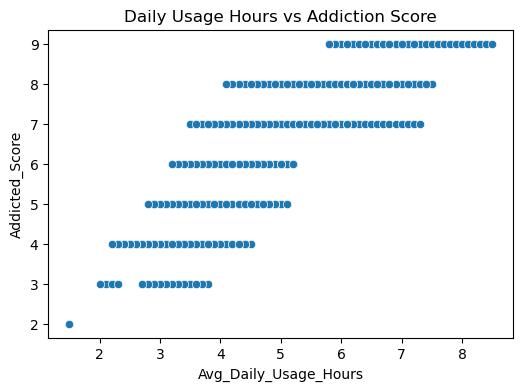

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="Avg_Daily_Usage_Hours", y=dep_var)
plt.title("Daily Usage Hours vs Addiction Score")
plt.show()

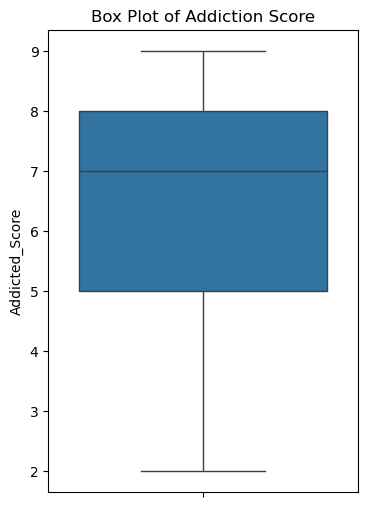

In [12]:
plt.figure(figsize=(4,6))
sns.boxplot(y=df[dep_var])
plt.title("Box Plot of Addiction Score")
plt.show()

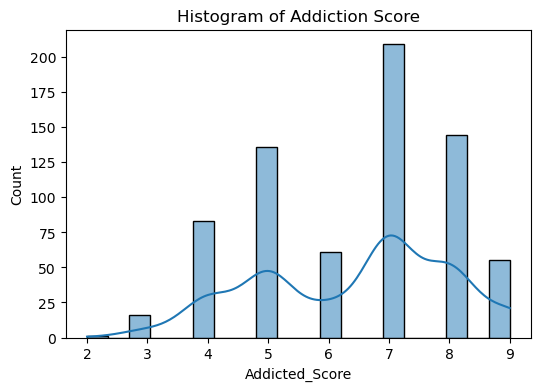

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df[dep_var], bins=20, kde=True)
plt.title("Histogram of Addiction Score")
plt.show()

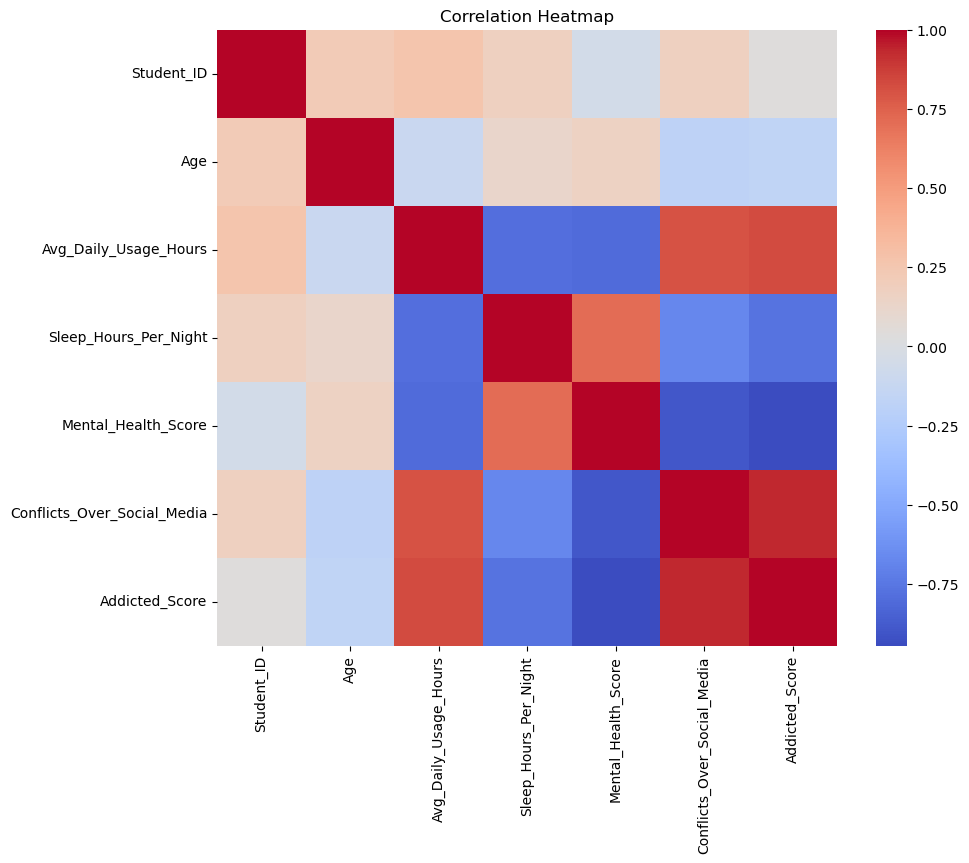

In [14]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
ind_num = "Avg_Daily_Usage_Hours"

clean = df[[ind_num, dep_var]].dropna()

pearson_corr, pearson_p = pearsonr(clean[ind_num], clean[dep_var])
spearman_corr, spearman_p = spearmanr(clean[ind_num], clean[dep_var])

print("Pearson correlation:", pearson_corr, "p-value:", pearson_p)
print("Spearman correlation:", spearman_corr, "p-value:", spearman_p)

Pearson correlation: 0.8320001573523101 p-value: 4.702147098834637e-182
Spearman correlation: 0.8379976167783714 p-value: 4.157435155279225e-187


In [16]:
cat_ind = "Gender"
cat_dep = "Affects_Academic_Performance"

table = pd.crosstab(df[cat_ind], df[cat_dep])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print(table)

Chi-square statistic: 0.33430703054514305
p-value: 0.5631338912008489
Degrees of freedom: 1
Affects_Academic_Performance   No  Yes
Gender                                
Female                        122  231
Male                          130  222


In [17]:
sample_data = df[dep_var].dropna()

t_stat, p_value = ttest_1samp(sample_data, popmean=50)

print("One-sample t-test:")
print("t-statistic:", t_stat)
print("p-value:", p_value)

One-sample t-test:
t-statistic: -728.7716694425786
p-value: 0.0
